In [1]:
n_jobs=-1

In [1]:
from pathlib import Path
from os import environ

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/rlct")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/rlct


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [3]:
from sklearn_extensions.mixpoisson import PoissonMixture
from scipy_extensions import mixpoisson


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
  return truth

def n_components_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  half_space = int(np.ceil(len(truth)/2))
  mus = truth[0: half_space]
  weights = truth[half_space: len(truth)]
  return mixpoisson.n_components(mus=mus, weights=weights)

def rlct_by_dsid(dsid: str, k: int):
  n_components0 = n_components_by_dsid(dsid)
  return mixpoisson.rlct(d=1, r=n_components0, k=k)

In [12]:
df = pd.read_csv(f"{outputdir}/watanabe_bias.csv")
# filter out the 0.1 and 0.5 d factors
df = df[df['hypers'] != 'c=1,d=0.1']
df = df[df['hypers'] != 'c=1,d=0.5']

df.head()

,dsid,regime,n,trial,rlct,hypers,name,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,duration
1,singular2,5000,5000,0,0.839289,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
3,singular2,5000,5000,1,0.905477,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
5,singular2,5000,5000,2,0.803190,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
7,singular2,5000,5000,3,0.712658,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
9,singular1,5000,5000,0,0.752198,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN


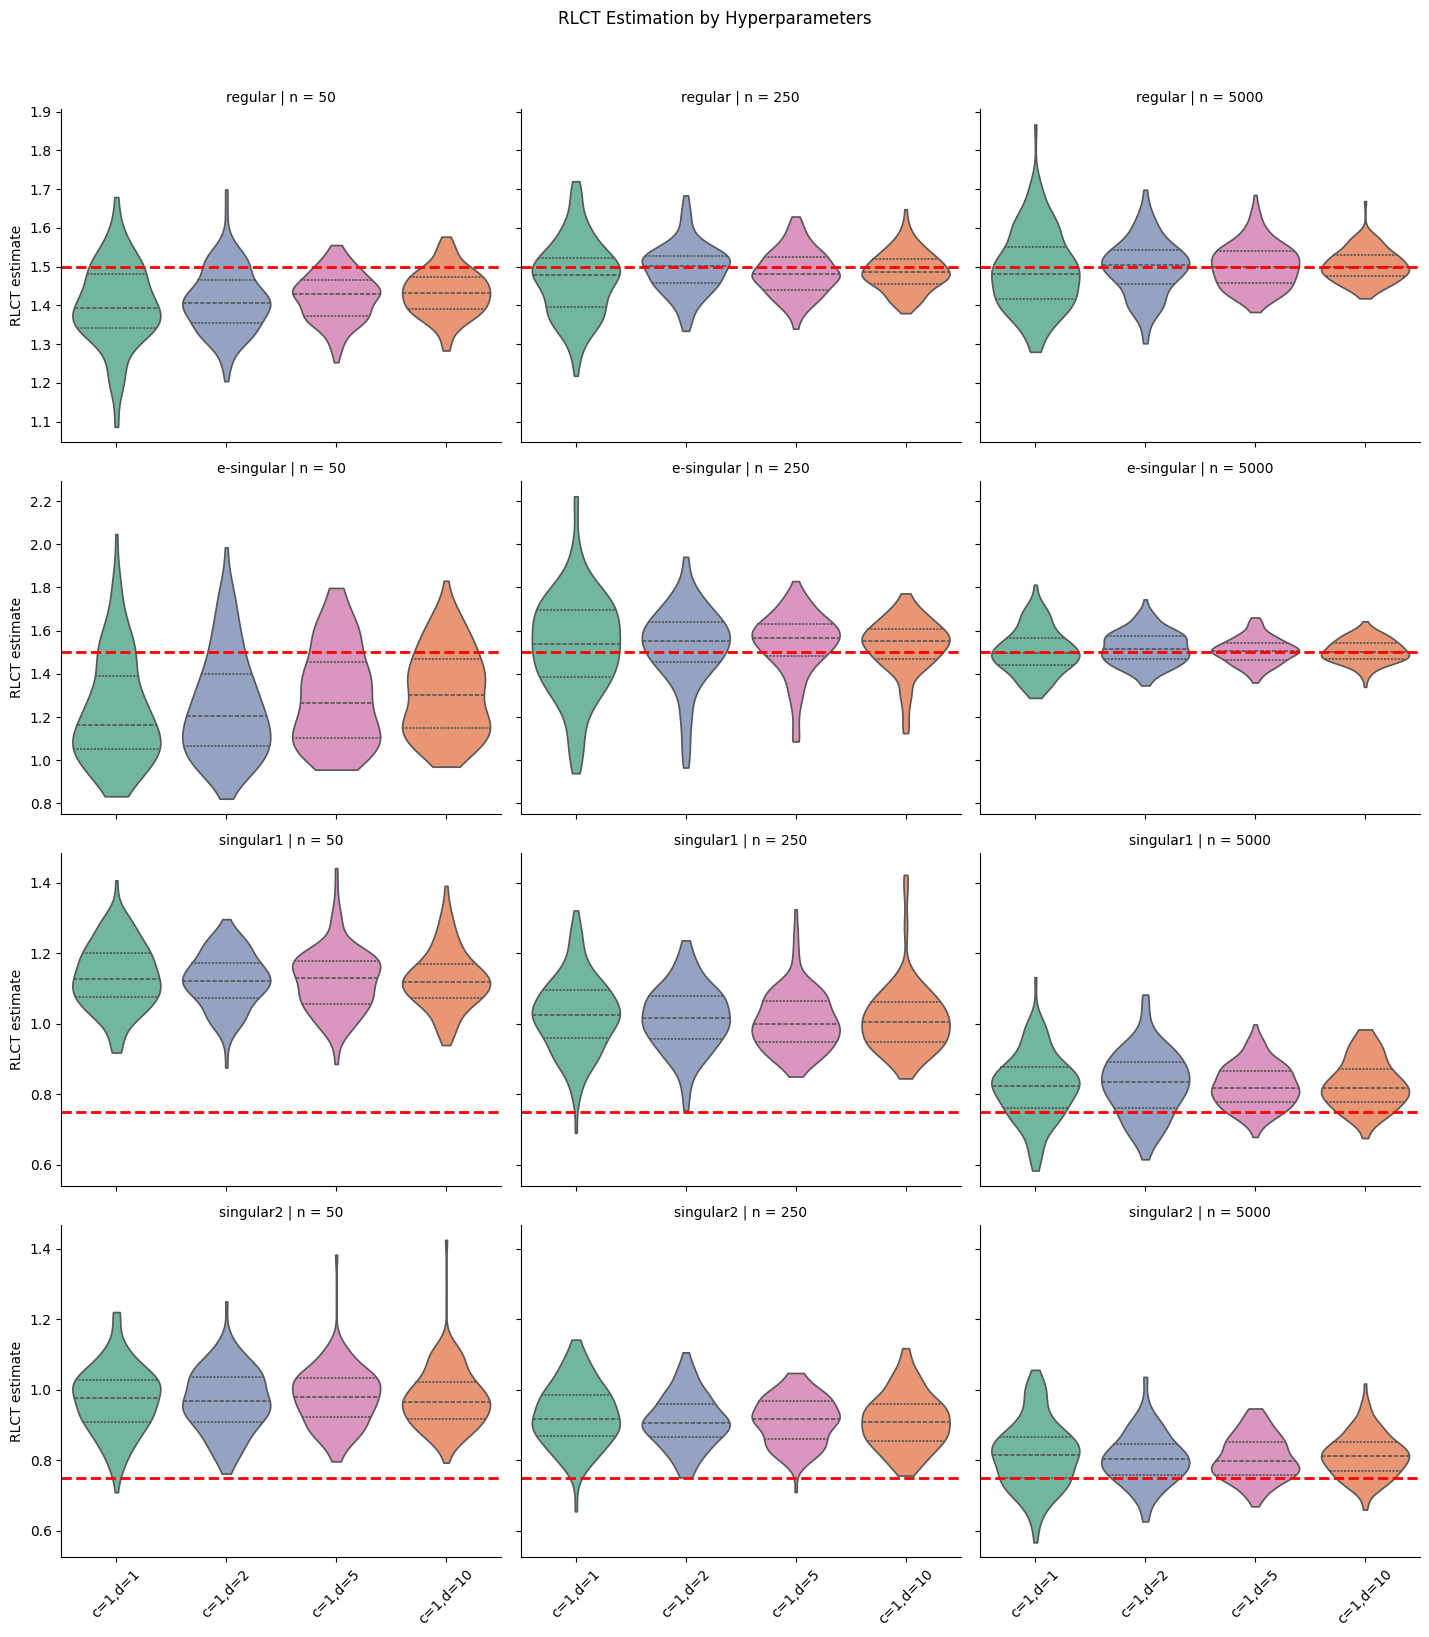

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dsids = df['dsid'].unique()
n_values = sorted(df['n'].unique())

g = sns.FacetGrid(
    df, 
    row='dsid', 
    col='n', 
    height=4, 
    aspect=1.2,
    sharey='row',
    row_order=dsids[::-1],
    col_order=n_values
)

g.map_dataframe(
    sns.violinplot, 
    x='hypers', 
    y='rlct', 
    hue='hypers',
    palette='Set2',
    legend=False,
    cut=0,  # Don't extend beyond data range
    inner='quart',  # Show quartiles inside violin
    order=['c=1,d=1', 'c=1,d=2', 'c=1,d=5', 'c=1,d=10']  # Add this line
)

# Add true RLCT lines to each row
for i, dsid in enumerate(dsids[::-1]):
    true_rlct = rlct_by_dsid(dsid, k=2)
    for j, n in enumerate(n_values):
        ax = g.axes[i, j]
        ax.axhline(true_rlct, color='red', linestyle='--', linewidth=2)

g.set_axis_labels('', 'RLCT estimate')
g.set_titles(row_template='{row_name}', col_template='n = {col_name}')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('RLCT Estimation by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

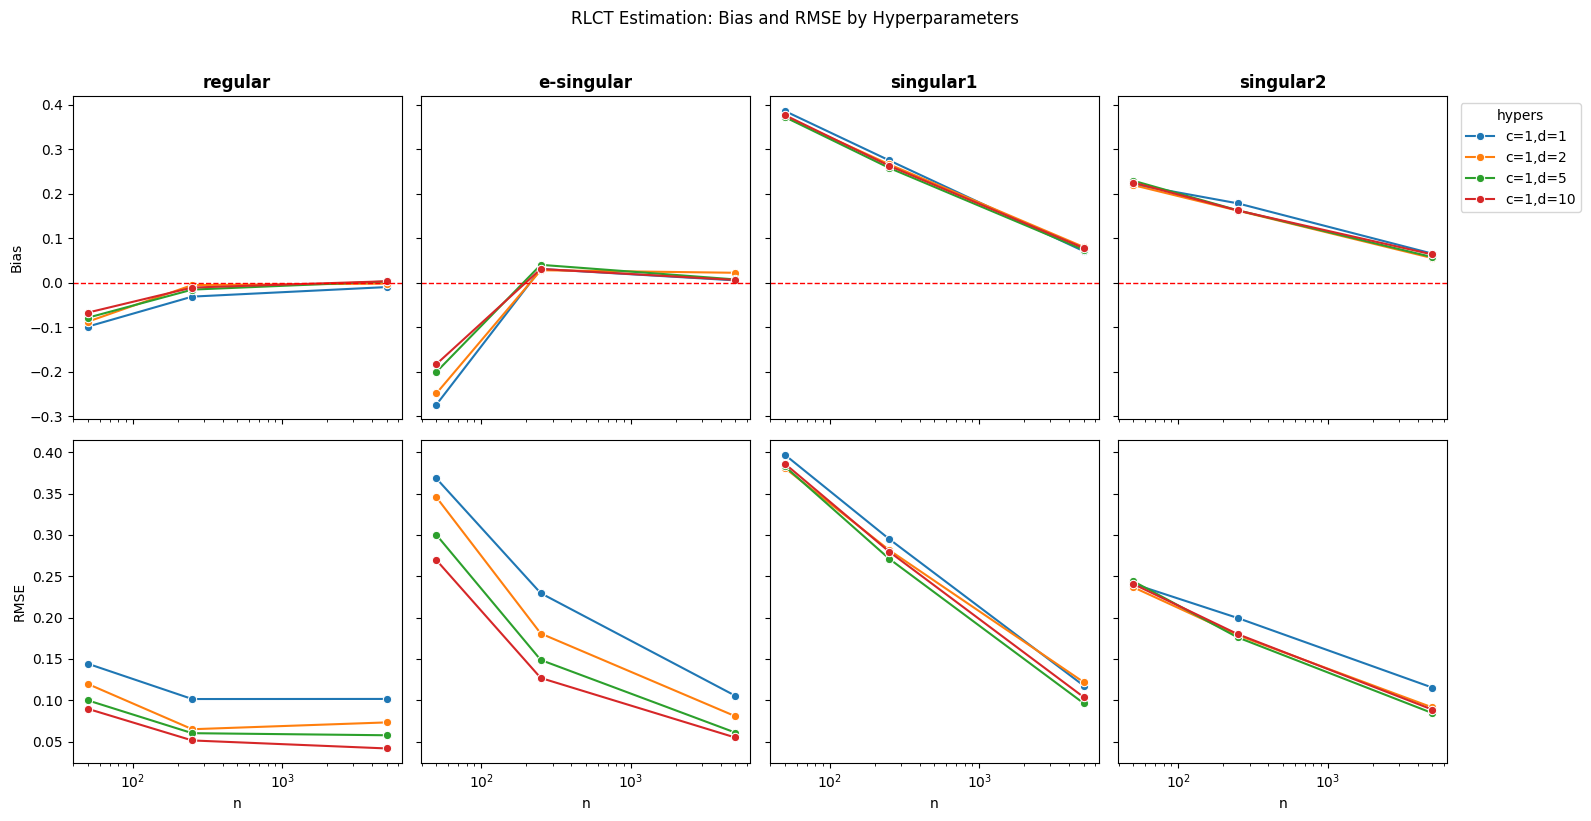

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std'),
    median_rlct=('rlct', 'median')
).reset_index()

# Add true RLCT and compute bias/rmse
summary['true_rlct'] = summary['dsid'].apply(lambda x: rlct_by_dsid(x, k=2))
summary['bias'] = summary['mean_rlct'] - summary['true_rlct']
summary['rmse'] = np.sqrt(summary['bias']**2 + summary['std_rlct']**2)

dsids = ['regular', 'e-singular', 'singular1', 'singular2']

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True, sharey='row')

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Bias
    ax = axes[0, j]
    sns.lineplot(
        data=data,
        x='n',
        y='bias',
        hue='hypers',
        marker='o',
        ax=ax,
        hue_order=['c=1,d=1', 'c=1,d=2', 'c=1,d=5', 'c=1,d=10']
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_title(dsid, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Bias' if j == 0 else '')
    
    if j < len(dsids) - 1:
        ax.get_legend().remove()
    else:
        ax.legend(title='hypers', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: RMSE
    ax = axes[1, j]
    sns.lineplot(data=data,
                 x='n',
                 y='rmse',
                 hue='hypers',
                 marker='o',
                 ax=ax,
                 hue_order=['c=1,d=1', 'c=1,d=2', 'c=1,d=5', 'c=1,d=10']
                )
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('RMSE' if j == 0 else '')
    ax.get_legend().remove()

plt.suptitle('RLCT Estimation: Bias and RMSE by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

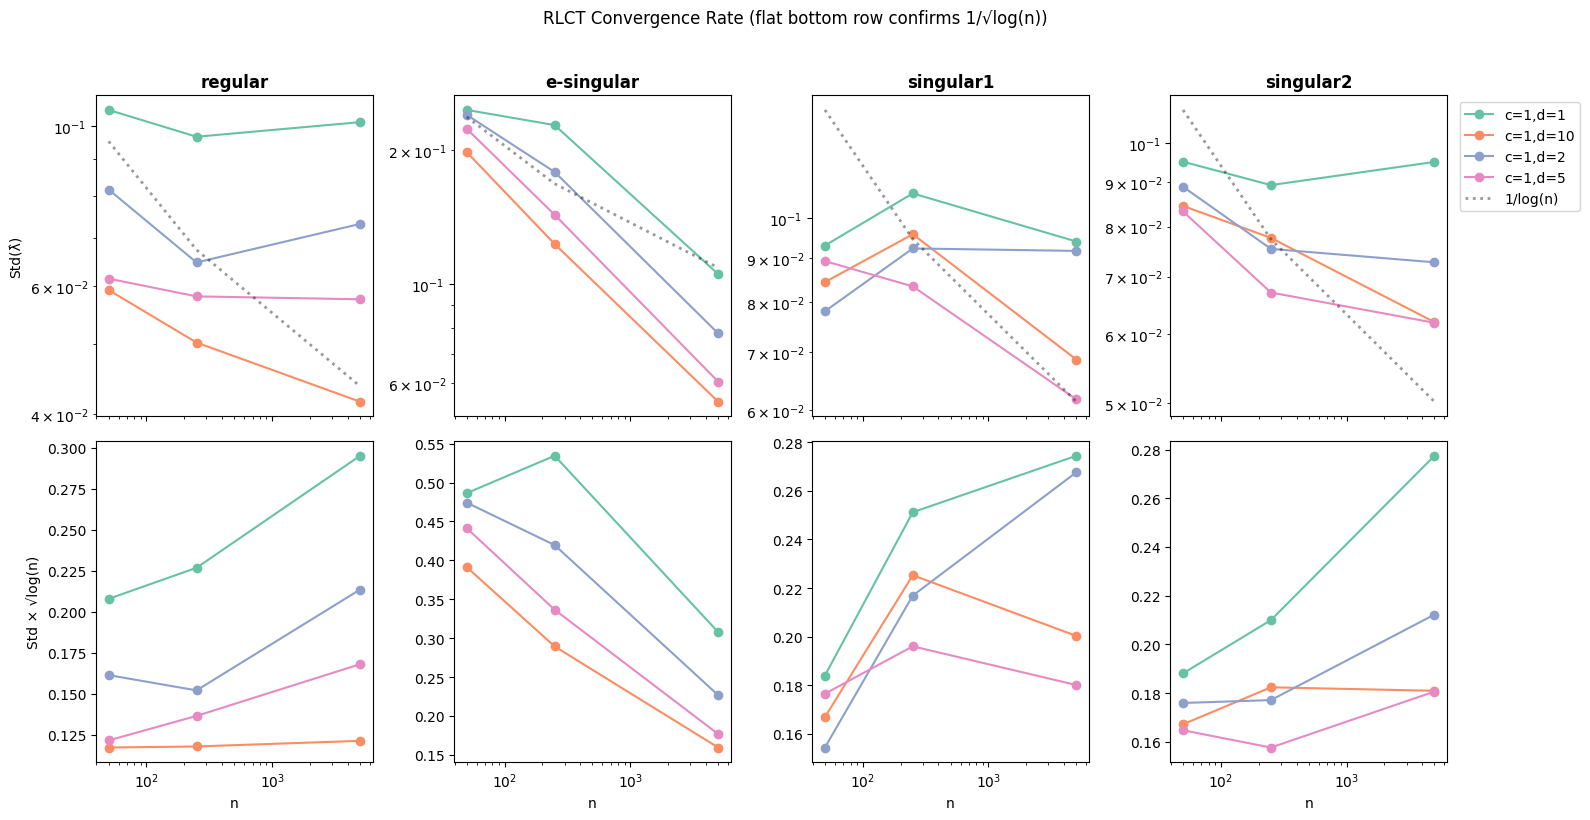

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std')
).reset_index()

summary['true_rlct'] = summary['dsid'].apply(lambda x: rlct_by_dsid(x, k=2))
summary['std_normalized'] = summary['std_rlct'] * np.sqrt(np.log(summary['n']))

dsids = ['regular', 'e-singular', 'singular1', 'singular2']
hypers_list = summary['hypers'].unique()
palette = sns.color_palette('Set2', len(hypers_list))
hyper_colors = dict(zip(hypers_list, palette))

n_range = np.array(sorted(summary['n'].unique()))

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True)

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Std with reference line
    ax = axes[0, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_rlct'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    # Reference line anchored at midpoint
    mid_idx = len(n_range) // 2
    ref_n = n_range[mid_idx]
    ref_std = data.groupby('n')['std_rlct'].mean().iloc[mid_idx]
    
    ax.plot(n_range, ref_std * (np.log(ref_n) / np.log(n_range)), 
            'k:', alpha=0.4, linewidth=2, label='1/log(n)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('Std(λ̂)' if j == 0 else '')
    ax.set_title(dsid, fontweight='bold')
    
    if j == len(dsids) - 1:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: Std × √log(n)
    ax = axes[1, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_normalized'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('Std × √log(n)' if j == 0 else '')
    ax.get_legend().remove() if ax.get_legend() else None

plt.suptitle('RLCT Convergence Rate (flat bottom row confirms 1/√log(n))', y=1.02)
plt.tight_layout()
plt.show()